In [1]:
from scipy import stats as st
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

In [2]:
import pandas as pd

users = pd.read_csv('datasets/users.csv')
calls = pd.read_csv('datasets/calls.csv')
messages = pd.read_csv('datasets/messages.csv')
internet = pd.read_csv('datasets/internet.csv')
tariffs = pd.read_csv('datasets/tariffs.csv')

## Предобработка данных

### Таблица users

In [3]:
users.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [4]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     500 non-null    int64
 1   age         500 non-null    int64
 2   churn_date  38 non-null     str  
 3   city        500 non-null    str  
 4   first_name  500 non-null    str  
 5   last_name   500 non-null    str  
 6   reg_date    500 non-null    str  
 7   tariff      500 non-null    str  
dtypes: int64(2), str(6)
memory usage: 60.7 KB


In [5]:
users['churn_date'] = pd.to_datetime(users['churn_date'])
users['reg_date'] = pd.to_datetime(users['reg_date'])
users[users.churn_date.notna()].head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
19,1019,63,2018-10-05,Томск,Игнатий,Круглов,2018-05-16,ultra
20,1020,59,2018-12-18,Чита,Тала,Костина,2018-10-22,smart
34,1034,66,2018-11-21,Вологда,Святослав,Бондарев,2018-08-26,smart
50,1050,44,2018-10-03,Тюмень,Рузана,Аничкина,2018-06-16,ultra
51,1051,37,2018-10-14,Москва,Кристина,Сомова,2018-05-28,smart


In [6]:
users.city.unique()

<ArrowStringArray>
[       'Краснодар',           'Москва',      'Стерлитамак',
      'Новокузнецк', 'Набережные Челны',        'Ульяновск',
        'Челябинск',            'Пермь',           'Тюмень',
           'Самара',  'Санкт-Петербург',          'Иваново',
        'Чебоксары',             'Омск',              'Уфа',
            'Томск',             'Чита',         'Мурманск',
     'Петрозаводск',            'Тверь',     'Екатеринбург',
        'Махачкала',          'Вологда',        'Череповец',
        'Ярославль',             'Сочи',        'Хабаровск',
       'Ставрополь',           'Рязань',         'Улан-Удэ',
             'Тула',          'Саратов',   'Ростов-на-Дону',
           'Казань',          'Иркутск',            'Курск',
           'Калуга',           'Якутск',        'Астрахань',
            'Химки',      'Владикавказ',        'Волгоград',
          'Саранск',           'Ижевск',      'Новосибирск',
           'Брянск',         'Тольятти',     'Нижний Тагил',
     

In [7]:
users.tariff.unique()

<ArrowStringArray>
['ultra', 'smart']
Length: 2, dtype: str

In [8]:
users.select_dtypes(include='object').describe()

C:\Users\alexander\AppData\Local\Temp\ipykernel_288\191316296.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  users.select_dtypes(include='object').describe()


,city,first_name,last_name,tariff
count,500,500,500,500
unique,76,246,419,2
top,Москва,Радим,Андреенко,smart
freq,99,6,5,351


In [9]:
users.describe()

,user_id,age,churn_date,reg_date
count,500.000000,500.00000,38,500
mean,1249.500000,46.58800,2018-11-13 00:37:53.684210,2018-06-30 18:57:36
min,1000.000000,18.00000,2018-08-17 00:00:00,2018-01-01 00:00:00
25%,1124.750000,32.00000,2018-10-14 00:00:00,2018-04-07 12:00:00
50%,1249.500000,46.00000,2018-11-24 00:00:00,2018-07-02 12:00:00
75%,1374.250000,62.00000,2018-12-15 12:00:00,2018-09-29 00:00:00
max,1499.000000,75.00000,2018-12-30 00:00:00,2018-12-31 00:00:00
std,144.481833,16.66763,NaN,NaN


In [10]:
users.duplicated().sum()

np.int64(0)

### Таблица calls

In [11]:
calls.head()

,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000


<Axes: >

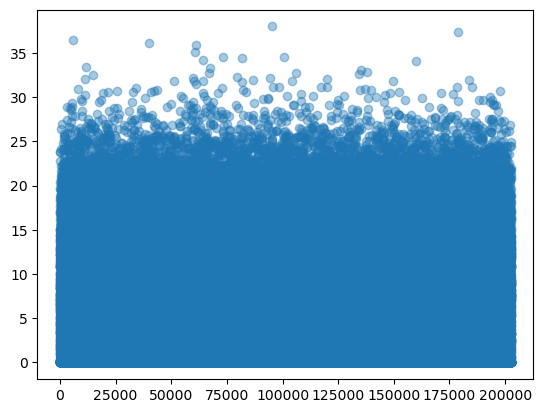

In [12]:
calls.duration.plot(style='o', alpha=0.4)

In [13]:
calls.info()

<class 'pandas.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         202607 non-null  str    
 1   call_date  202607 non-null  str    
 2   duration   202607 non-null  float64
 3   user_id    202607 non-null  int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 9.6 MB


In [14]:
calls['call_date'] = pd.to_datetime(calls['call_date'])

In [15]:
calls.user_id.nunique()

492

In [16]:
calls.describe()

,call_date,duration,user_id
count,202607,202607.000000,202607.000000
mean,2018-09-02 20:01:37.583992,6.755887,1253.940619
min,2018-01-01 00:00:00,0.000000,1000.000000
25%,2018-07-05 00:00:00,1.300000,1126.000000
50%,2018-09-17 00:00:00,6.000000,1260.000000
75%,2018-11-14 00:00:00,10.700000,1379.000000
max,2018-12-31 00:00:00,38.000000,1499.000000
std,NaN,5.843365,144.722751


In [17]:
calls.duplicated().sum()

np.int64(0)

### Таблица messages

In [18]:
messages.head()

,id,message_date,user_id
0,1000_0,2018-06-27,1000
1,1000_1,2018-10-08,1000
2,1000_2,2018-08-04,1000
3,1000_3,2018-06-16,1000
4,1000_4,2018-12-05,1000


In [19]:
messages.info()

<class 'pandas.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            123036 non-null  str  
 1   message_date  123036 non-null  str  
 2   user_id       123036 non-null  int64
dtypes: int64(1), str(2)
memory usage: 4.9 MB


In [20]:
messages['message_date'] = pd.to_datetime(messages['message_date'])

In [21]:
messages.message_date.describe()

count                        123036
mean     2018-09-04 15:28:42.227640
min             2018-01-02 00:00:00
25%             2018-07-09 00:00:00
50%             2018-09-20 00:00:00
75%             2018-11-14 00:00:00
max             2018-12-31 00:00:00
Name: message_date, dtype: object

In [22]:
messages.duplicated().sum()

np.int64(0)

### Таблица internet

In [23]:
internet.head()

,Unnamed: 0,id,mb_used,session_date,user_id
0,0,1000_0,112.95,2018-11-25,1000
1,1,1000_1,1052.81,2018-09-07,1000
2,2,1000_2,1197.26,2018-06-25,1000
3,3,1000_3,550.27,2018-08-22,1000
4,4,1000_4,302.56,2018-09-24,1000


In [24]:
internet.info()

<class 'pandas.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    149396 non-null  int64  
 1   id            149396 non-null  str    
 2   mb_used       149396 non-null  float64
 3   session_date  149396 non-null  str    
 4   user_id       149396 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 8.2 MB


In [25]:
internet = internet.drop('Unnamed: 0', axis=1)

In [26]:
internet.user_id.nunique()

497

In [27]:
internet.duplicated().sum()

np.int64(0)

In [28]:
internet.describe()

,mb_used,user_id
count,149396.000000,149396.000000
mean,370.192426,1252.099842
std,278.300951,144.050823
min,0.000000,1000.000000
25%,138.187500,1130.000000
50%,348.015000,1251.000000
75%,559.552500,1380.000000
max,1724.830000,1499.000000


In [29]:
internet.session_date = pd.to_datetime(internet.session_date)

In [30]:
internet.info()

<class 'pandas.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            149396 non-null  str           
 1   mb_used       149396 non-null  float64       
 2   session_date  149396 non-null  datetime64[us]
 3   user_id       149396 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 5.6 MB


In [31]:
internet.session_date.describe()

count                        149396
mean     2018-09-02 12:55:35.221826
min             2018-01-01 00:00:00
25%             2018-07-05 00:00:00
50%             2018-09-17 00:00:00
75%             2018-11-14 00:00:00
max             2018-12-31 00:00:00
Name: session_date, dtype: object

### Таблица tariffs

In [32]:
tariffs

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


In [33]:
tariffs.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   messages_included      2 non-null      int64
 1   mb_per_month_included  2 non-null      int64
 2   minutes_included       2 non-null      int64
 3   rub_monthly_fee        2 non-null      int64
 4   rub_per_gb             2 non-null      int64
 5   rub_per_message        2 non-null      int64
 6   rub_per_minute         2 non-null      int64
 7   tariff_name            2 non-null      str  
dtypes: int64(7), str(1)
memory usage: 270.0 bytes


## Рассчеты

In [34]:
calls.head()

,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000


In [35]:
calls['month'] = calls.call_date.dt.month

In [36]:
calls.head()

,id,call_date,duration,user_id,month
0,1000_0,2018-07-25,0.00,1000,7
1,1000_1,2018-08-17,0.00,1000,8
2,1000_2,2018-06-11,2.85,1000,6
3,1000_3,2018-09-21,13.80,1000,9
4,1000_4,2018-12-15,5.18,1000,12


In [37]:
user_info = (
    calls.groupby(['user_id', 'month'])
    .duration.agg({'count', 'sum'})
    .reset_index()
    .rename(columns={'count':'calls_count', 'sum':'minutes_spent'})
)
user_info

,user_id,month,minutes_spent,calls_count
0,1000,5,150.06,22
1,1000,6,158.90,43
2,1000,7,318.80,47
3,1000,8,389.87,52
4,1000,9,440.14,58
...,...,...,...,...
3169,1498,10,232.63,41
3170,1499,9,64.65,9
3171,1499,10,429.91,68
3172,1499,11,576.50,74


In [38]:
messages.head()

,id,message_date,user_id
0,1000_0,2018-06-27,1000
1,1000_1,2018-10-08,1000
2,1000_2,2018-08-04,1000
3,1000_3,2018-06-16,1000
4,1000_4,2018-12-05,1000


In [39]:
messages['month'] = messages.message_date.dt.month

In [40]:
grouped_messages = (
    messages.groupby(['user_id', 'month'])
    .id.count()
    .reset_index()
    .rename(columns={'id':'message_count'})
)
grouped_messages.shape[0]

2717

In [41]:
user_info = user_info.merge(grouped_messages, how='outer')
user_info

,user_id,month,minutes_spent,calls_count,message_count
0,1000,5,150.06,22.0,22.0
1,1000,6,158.90,43.0,60.0
2,1000,7,318.80,47.0,75.0
3,1000,8,389.87,52.0,81.0
4,1000,9,440.14,58.0,57.0
...,...,...,...,...,...
3208,1498,10,232.63,41.0,42.0
3209,1499,9,64.65,9.0,11.0
3210,1499,10,429.91,68.0,48.0
3211,1499,11,576.50,74.0,59.0


In [42]:
internet.head()

,id,mb_used,session_date,user_id
0,1000_0,112.95,2018-11-25,1000
1,1000_1,1052.81,2018-09-07,1000
2,1000_2,1197.26,2018-06-25,1000
3,1000_3,550.27,2018-08-22,1000
4,1000_4,302.56,2018-09-24,1000


In [43]:
internet['month'] = internet.session_date.dt.month

In [44]:
grouped_internet = (
    internet.groupby(['user_id', 'month'])
    .mb_used.sum()
    .reset_index()
)
grouped_internet.head()

,user_id,month,mb_used
0,1000,5,2253.49
1,1000,6,23233.77
2,1000,7,14003.64
3,1000,8,14055.93
4,1000,9,14568.91


In [45]:
user_info = user_info.merge(grouped_internet, how='outer')
user_info

,user_id,month,minutes_spent,calls_count,message_count,mb_used
0,1000,5,150.06,22.0,22.0,2253.49
1,1000,6,158.90,43.0,60.0,23233.77
2,1000,7,318.80,47.0,75.0,14003.64
3,1000,8,389.87,52.0,81.0,14055.93
4,1000,9,440.14,58.0,57.0,14568.91
...,...,...,...,...,...,...
3209,1498,10,232.63,41.0,42.0,20579.36
3210,1499,9,64.65,9.0,11.0,1845.75
3211,1499,10,429.91,68.0,48.0,17788.51
3212,1499,11,576.50,74.0,59.0,17963.31


In [46]:
user_info = user_info.merge(users[['user_id', 'tariff']], how='outer', on='user_id')
user_info

,user_id,month,minutes_spent,calls_count,message_count,mb_used,tariff
0,1000,5.0,150.06,22.0,22.0,2253.49,ultra
1,1000,6.0,158.90,43.0,60.0,23233.77,ultra
2,1000,7.0,318.80,47.0,75.0,14003.64,ultra
3,1000,8.0,389.87,52.0,81.0,14055.93,ultra
4,1000,9.0,440.14,58.0,57.0,14568.91,ultra
...,...,...,...,...,...,...,...
3211,1498,10.0,232.63,41.0,42.0,20579.36,smart
3212,1499,9.0,64.65,9.0,11.0,1845.75,smart
3213,1499,10.0,429.91,68.0,48.0,17788.51,smart
3214,1499,11.0,576.50,74.0,59.0,17963.31,smart


In [47]:
tariffs

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


In [48]:
user_info = user_info.merge(tariffs.rename(columns={'tariff_name':'tariff'}), on='tariff')
user_info

,user_id,month,minutes_spent,calls_count,message_count,mb_used,tariff,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute
0,1000,5.0,150.06,22.0,22.0,2253.49,ultra,1000,30720,3000,1950,150,1,1
1,1000,6.0,158.90,43.0,60.0,23233.77,ultra,1000,30720,3000,1950,150,1,1
2,1000,7.0,318.80,47.0,75.0,14003.64,ultra,1000,30720,3000,1950,150,1,1
3,1000,8.0,389.87,52.0,81.0,14055.93,ultra,1000,30720,3000,1950,150,1,1
4,1000,9.0,440.14,58.0,57.0,14568.91,ultra,1000,30720,3000,1950,150,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3211,1498,10.0,232.63,41.0,42.0,20579.36,smart,50,15360,500,550,200,3,3
3212,1499,9.0,64.65,9.0,11.0,1845.75,smart,50,15360,500,550,200,3,3
3213,1499,10.0,429.91,68.0,48.0,17788.51,smart,50,15360,500,550,200,3,3
3214,1499,11.0,576.50,74.0,59.0,17963.31,smart,50,15360,500,550,200,3,3


### Рассчет выручки за каждого пользователя в месяц

In [49]:
import numpy as np

user_info['gb_used'] = np.ceil(user_info.mb_used / 1024)
user_info['mb_per_month_included'] = user_info['mb_per_month_included'] // 1024
user_info = user_info.drop('mb_used', axis=1).rename(columns={'mb_per_month_included':'gb_included'})
user_info['minutes_spent'] = np.ceil(user_info['minutes_spent'])
user_info.head()

,user_id,month,minutes_spent,calls_count,message_count,tariff,messages_included,gb_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,gb_used
0,1000,5.0,151.0,22.0,22.0,ultra,1000,30,3000,1950,150,1,1,3.0
1,1000,6.0,159.0,43.0,60.0,ultra,1000,30,3000,1950,150,1,1,23.0
2,1000,7.0,319.0,47.0,75.0,ultra,1000,30,3000,1950,150,1,1,14.0
3,1000,8.0,390.0,52.0,81.0,ultra,1000,30,3000,1950,150,1,1,14.0
4,1000,9.0,441.0,58.0,57.0,ultra,1000,30,3000,1950,150,1,1,15.0


In [50]:
user_info['revenue'] = (
    user_info.rub_monthly_fee
    + np.where(
        user_info.message_count > user_info.messages_included,
        (user_info.message_count - user_info.messages_included) * user_info.rub_per_message, 
        0
    )
    + np.where(
        user_info.gb_used > user_info.gb_included,
        (user_info.gb_used - user_info.gb_included) * user_info.rub_per_gb,
        0    
    )
    + np.where(
        user_info.minutes_spent > user_info.minutes_included,
        (user_info.minutes_spent - user_info.minutes_included) * user_info.rub_per_minute,
        0    
    )
)
user_info

,user_id,month,minutes_spent,calls_count,message_count,tariff,messages_included,gb_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,gb_used,revenue
0,1000,5.0,151.0,22.0,22.0,ultra,1000,30,3000,1950,150,1,1,3.0,1950.0
1,1000,6.0,159.0,43.0,60.0,ultra,1000,30,3000,1950,150,1,1,23.0,1950.0
2,1000,7.0,319.0,47.0,75.0,ultra,1000,30,3000,1950,150,1,1,14.0,1950.0
3,1000,8.0,390.0,52.0,81.0,ultra,1000,30,3000,1950,150,1,1,14.0,1950.0
4,1000,9.0,441.0,58.0,57.0,ultra,1000,30,3000,1950,150,1,1,15.0,1950.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3211,1498,10.0,233.0,41.0,42.0,smart,50,15,500,550,200,3,3,21.0,1750.0
3212,1499,9.0,65.0,9.0,11.0,smart,50,15,500,550,200,3,3,2.0,550.0
3213,1499,10.0,430.0,68.0,48.0,smart,50,15,500,550,200,3,3,18.0,1150.0
3214,1499,11.0,577.0,74.0,59.0,smart,50,15,500,550,200,3,3,18.0,1408.0


In [51]:
user_info = user_info[['user_id', 'month', 'minutes_spent', 'message_count', 'gb_used', 'tariff', 'revenue']]

## Анализ данных

In [52]:
user_info.head()

,user_id,month,minutes_spent,message_count,gb_used,tariff,revenue
0,1000,5.0,151.0,22.0,3.0,ultra,1950.0
1,1000,6.0,159.0,60.0,23.0,ultra,1950.0
2,1000,7.0,319.0,75.0,14.0,ultra,1950.0
3,1000,8.0,390.0,81.0,14.0,ultra,1950.0
4,1000,9.0,441.0,57.0,15.0,ultra,1950.0


In [53]:
users.query('tariff == "ultra"').shape[0]

149

In [54]:
users.query('tariff == "smart"').shape[0]

351

Посчитаем для каждого пользователя среднее значение параметров в месяц

In [55]:
users_ultra = (
    user_info
    .query('tariff == "ultra"')
    .drop(['tariff', 'month'], axis=1)
    .groupby('user_id').mean()
)
users_smart = (
    user_info
    .query('tariff == "smart"')
    .drop(['tariff', 'month'], axis=1)
    .groupby('user_id').mean()
)
users_ultra

,minutes_spent,message_count,gb_used,revenue
user_id,,,,
1000,302.750000,62.000,13.625000,1950.0
1003,720.600000,76.000,11.800000,1950.0
1004,115.750000,149.000,18.750000,1950.0
1013,444.000000,21.000,15.500000,1950.0
1016,58.000000,71.000,13.500000,1950.0
...,...,...,...,...
1476,497.625000,5.625,16.888889,1950.0
1485,548.000000,155.000,23.000000,1950.0
1491,483.666667,48.000,18.000000,1950.0


In [56]:
users_smart

,minutes_spent,message_count,gb_used,revenue
user_id,,,,
1001,400.500000,NaN,16.000000,850.000000
1002,204.857143,10.0,16.714286,1035.714286
1005,520.666667,46.0,8.583333,753.750000
1006,299.636364,NaN,15.090909,931.818182
1007,460.333333,25.0,14.888889,874.111111
...,...,...,...,...
1494,366.000000,NaN,15.600000,990.000000
1496,472.250000,39.0,22.500000,2308.333333
1497,442.333333,17.0,15.333333,899.333333


### Минуты

count     143.000000
mean      516.580292
std       253.112247
min         9.285714
25%       324.700000
50%       497.625000
75%       708.000000
max      1114.727273
Name: minutes_spent, dtype: float64

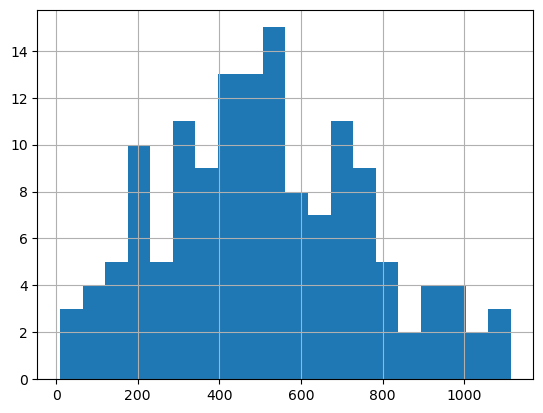

In [57]:
users_ultra.minutes_spent.hist(bins=20)
users_ultra.minutes_spent.describe()

count    349.000000
mean     397.697371
std      135.570316
min       12.090909
25%      299.636364
50%      401.500000
75%      491.400000
max      843.000000
Name: minutes_spent, dtype: float64

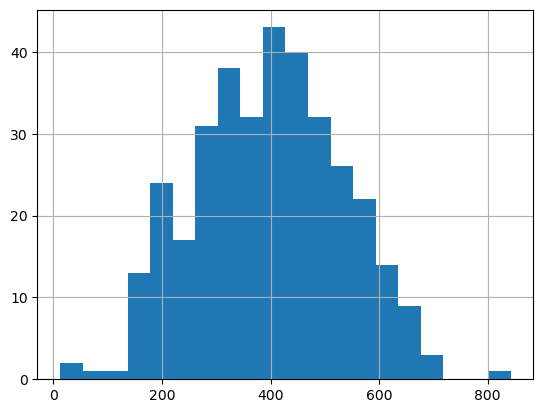

In [58]:
users_smart.minutes_spent.hist(bins=20)
users_smart.minutes_spent.describe()

### Сообщения

count    124.000000
mean      64.555802
std       43.390612
min        3.000000
25%       28.000000
50%       57.800000
75%       89.000000
max      192.000000
Name: message_count, dtype: float64

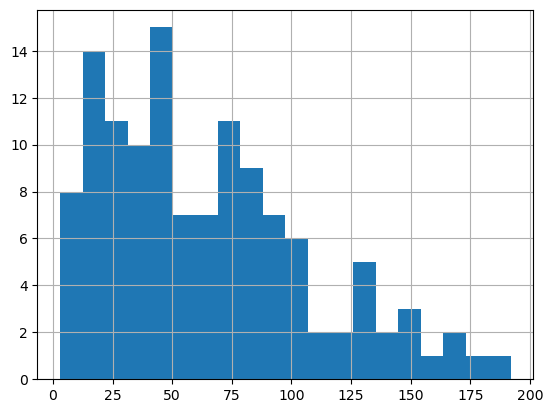

In [59]:
users_ultra.message_count.hist(bins=20)
users_ultra.message_count.describe()

count    302.000000
mean      37.575606
std       24.849738
min        1.000000
25%       19.000000
50%       33.000000
75%       54.000000
max      118.000000
Name: message_count, dtype: float64

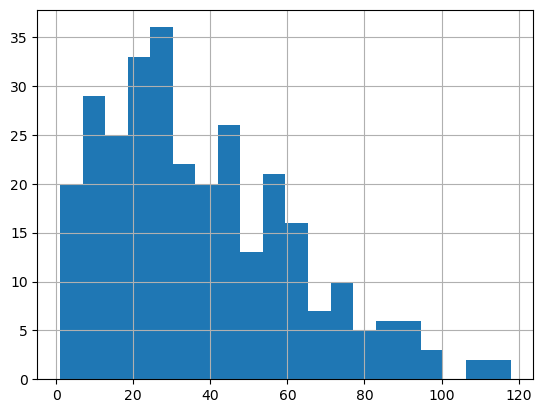

In [60]:
users_smart.message_count.hist(bins=20)
users_smart.message_count.describe()

### Интернет

count    147.000000
mean      19.740824
std        7.970582
min        2.500000
25%       15.000000
50%       18.800000
75%       25.791667
max       38.500000
Name: gb_used, dtype: float64

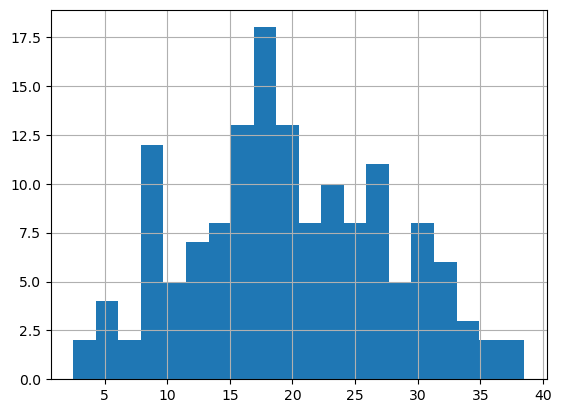

In [61]:
users_ultra.gb_used.hist(bins=20)
users_ultra.gb_used.describe()

count    350.000000
mean      16.318233
std        3.498822
min        5.727273
25%       14.027778
50%       16.333333
75%       18.691667
max       27.250000
Name: gb_used, dtype: float64

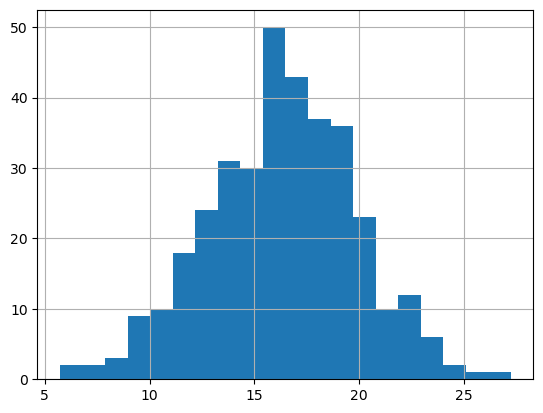

In [62]:
users_smart.gb_used.hist(bins=20)
users_smart.gb_used.describe()

## Проверка гипотез

### t-test

1. $H_0$ - средняя выручка пользователей тарифов «Ультра» и «Смарт» одинакова\
   $H_1$ - средняя выручка пользователей тарифов «Ультра» и «Смарт» различается

count     149.000000
mean     2085.548788
std       297.732421
min      1950.000000
25%      1950.000000
50%      1950.000000
75%      1987.500000
max      3225.000000
Name: revenue, dtype: float64

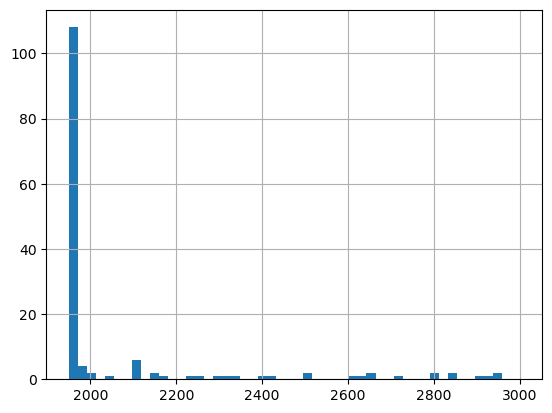

In [63]:
users_ultra.revenue.hist(bins=50, range=(1950, 3000))
users_ultra.revenue.describe()

count     351.000000
mean     1288.797619
std       592.597702
min       550.000000
25%       843.925000
50%      1150.000000
75%      1650.000000
max      4241.333333
Name: revenue, dtype: float64

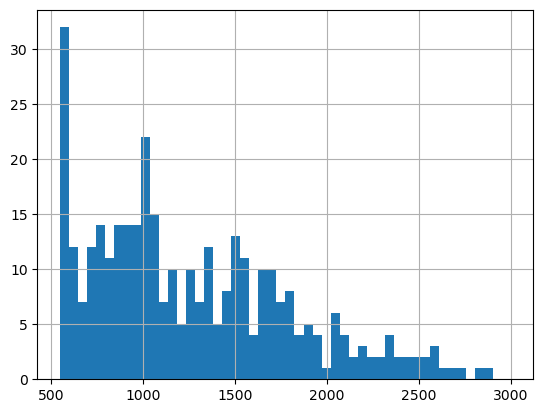

In [64]:
users_smart.revenue.hist(bins=50, range=(550, 3000))
users_smart.revenue.describe()

In [65]:
alpha = 0.05
result = st.ttest_ind(users_ultra.revenue, users_smart.revenue, equal_var=False)

print('p-value =', result.pvalue)
if result.pvalue > alpha: print('Не получилось опровергнуть нулевую гепотезу')
else: print('Отвергаем нулевую гепотезу')

p-value = 4.46525380299289e-65
Отвергаем нулевую гепотезу


2. $H_0$ - средняя выручка пользователей из Москвы не отличается от выручки пользователей из других регионов.\
   $H_1$ - средняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов.
   

In [66]:
user_info = user_info.merge(users[['city', 'user_id']], how='outer', on='user_id')

In [67]:
users_moscow = (
    user_info
    .query('city == "Москва"')
    .drop(['tariff', 'month', 'city'], axis=1)
    .groupby('user_id').mean()
)
users_other_cities = (
    user_info
    .query('city != "Москва"')
    .drop(['tariff', 'month', 'city'], axis=1)
    .groupby('user_id').mean()
)

count      99.000000
mean     1476.009353
std       608.271998
min       550.000000
25%       946.950000
50%      1570.375000
75%      1950.000000
max      2868.000000
Name: revenue, dtype: float64

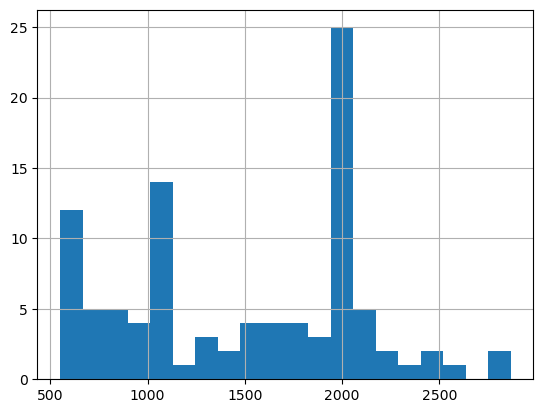

In [68]:
users_moscow.revenue.hist(bins=20)
users_moscow.revenue.describe()

count     401.000000
mean     1538.627950
std       643.931098
min       550.000000
25%       974.200000
50%      1550.833333
75%      1950.000000
max      4241.333333
Name: revenue, dtype: float64

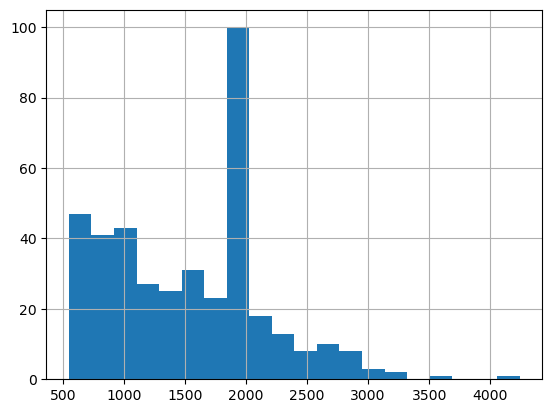

In [69]:
users_other_cities.revenue.hist(bins=20)
users_other_cities.revenue.describe()

In [114]:
result = st.ttest_ind(users_moscow.revenue, users_other_cities.revenue, equal_var=False)

print('p-value =', result.pvalue)
if result.pvalue > alpha: print('Не получилось опровергнуть нулевую гепотезу')
else: print('Отвергаем нулевую гепотезу')

p-value = 0.36604611763421646
Не получилось опровергнуть нулевую гепотезу


Для проверки гипотезы использован t-тест Уэлча, не предполагающий равенства дисперсий в сравниваемых группах.

### Permutation test

Проверим нулевую гипотезу с помощью перестановочного теста:

In [167]:
observed_diff = np.abs(users_moscow.revenue.mean() - users_other_cities.revenue.mean())
perm_diffs = []

for _ in range(20000):
    shuffled = users_combined.sample(frac=1, replace=False).reset_index(drop=True)
    group1 = shuffled.iloc[:len(users_moscow)]
    group2 = shuffled.iloc[len(users_moscow):]
    perm_diffs.append(np.abs(group1.mean() - group2.mean()))

p_value = np.mean(perm_diffs >= observed_diff)
p_value

np.float64(0.3748)

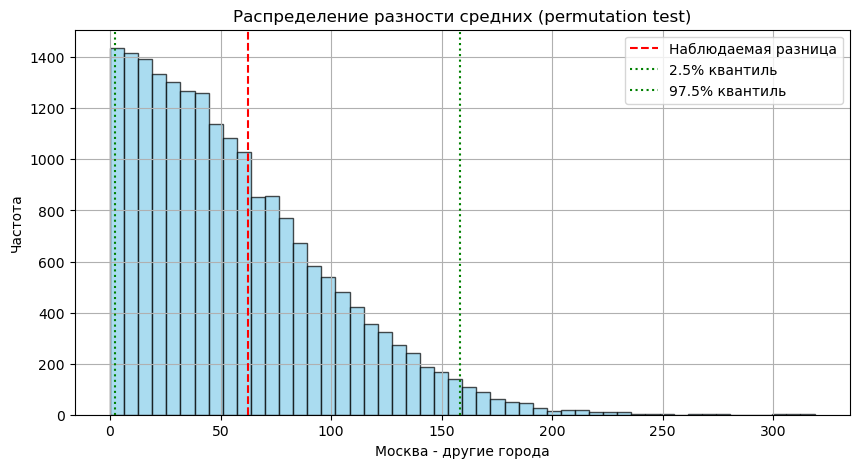

In [169]:
# Доверительный интервал (95%)
lower_bound = np.percentile(perm_diffs, 2.5)
upper_bound = np.percentile(perm_diffs, 97.5)

# Визуализация
plt.figure(figsize=(10, 5))
plt.hist(perm_diffs, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(observed_diff, color='red', linestyle='--', label='Наблюдаемая разница')
plt.axvline(lower_bound, color='green', linestyle=':', label='2.5% квантиль')
plt.axvline(upper_bound, color='green', linestyle=':', label='97.5% квантиль')

plt.title('Распределение разности средних (permutation test)')
plt.xlabel('Москва - другие города')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.show()


На графике представлено распределение разности средних, полученное с помощью перестановочного теста при условии справедливости нулевой гипотезы. Наблюдаемая разность средних находится в центральной части распределения, что подтверждает отсутствие статистически значимых различий между группами.

### Bootstrap 

С помощью bootstrap оценим устойчивость разницы средних значений выручки между группами. На основе полученного распределения построим доверительный интервал.

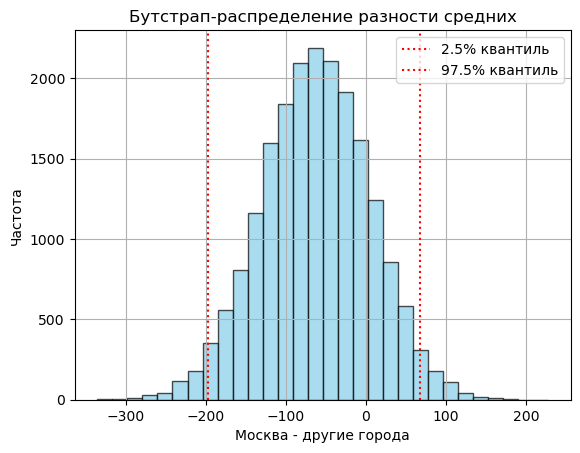

In [172]:
boot_diffs = []
for _ in range(20000):
    boot_moscow = users_moscow.revenue.sample(frac=1, replace=True)
    boot_other  = users_other_cities.revenue.sample(frac=1, replace=True)
    boot_diffs += [boot_moscow.mean() - boot_other.mean()]

left = np.percentile(boot_diffs, 2.5)
right = np.percentile(boot_diffs, 97.5)

plt.hist(np.array(boot_diffs), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(left, color='red', linestyle=':', label='2.5% квантиль')
plt.axvline(right, color='red', linestyle=':', label='97.5% квантиль')
plt.title('Бутстрап-распределение разности средних')
plt.xlabel('Москва - другие города')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.show()

Из полученного распределения видно, что 0 входит в доверительный интервал, а значит, статистически значимой разницы между доходами жителей Москвы и жителей других городов не наблюдается.